# Environment Setup

Download needed Libraries

In [2]:
!pip install torch torchvision scikit-learn numpy matplotlib

Import the libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import numpy as np
import os
from google.colab import drive
print("GPU is available:", torch.cuda.is_available())

GPU is available: False


Connect to Drive

*necessary to save embeddings while the model trains*

In [2]:
drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/simclr_model_cw2.pth'
EMBEDDINGS_PATH = '/content/drive/MyDrive/embeddings_cw2.npy'
LABELS_PATH = '/content/drive/MyDrive/labels_cw2.npy'
print("Drive mounted successfully")

Mounted at /content/drive
Drive mounted successfully


# Embeddings

SimCLR Augmentation and Dataset

In [4]:
# does the simclr augmentations as described in the paper
def get_augmented_data():
    return transforms.Compose([
        transforms.RandomResizedCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.RandomGrayscale(p=0.2), #20% chance of being grayscale
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
    ])

# dataset class that returns 2 views of each image
class SimCLRDataset(torch.utils.data.Dataset):
    def __init__(self, transform):
        # downloads the CIFAR images
        self.dataset = torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=None)
        self.transform = transform

    def __len__(self):
        return len(self.dataset) # 50,000 images in the dataset

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        view1 = self.transform(image)
        view2 = self.transform(image)
        # view1 and view2 different cause augmentation is randomized
        return view1, view2

simclr_dataset = SimCLRDataset(get_augmented_data()) # doesn't actually do any data processing yet - just configuration
# batch size as provided in research paper
simclr_loader = DataLoader(simclr_dataset,batch_size=512,shuffle=True,drop_last=True)

print(f"Size of dataset: {len(simclr_dataset)}")
print(f"Number of batches: {len(simclr_loader)}")

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Size of dataset: 50000
Number of batches: 97


SimCLR Model Creation

*tested with dummy images to verify before actual training*

In [3]:
#just builds the structure of the model
class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=None) # without any pre-trained weights
        # resnet.children() returns the layers like convolutional layers, relu, etc.
        # last layer removed because we want the output of the second last layer - 512 dimensional output
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        # gets the 512 dim down to 128 as per the paper
        self.projection = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        h = self.backbone(x)
        h = h.view(h.size(0), -1) # flattens the previous output
        z = self.projection(h) # 128 dimensional output
        return h, z

# testing with a dummy to avoid future errors before the actual training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"CPU or GPU being used: {device}")
test_model = SimCLR().to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
h, z = test_model(dummy)
print(f"Intermediate flattened shape (h): {h.shape}")   # should be (2, 512)
print(f"Final shape (z): {z.shape}") # should be (2, 128)

#free's gpu space
del test_model, dummy

CPU or GPU being used: cpu
Intermediate flattened shape (h): torch.Size([2, 512])
Final shape (z): torch.Size([2, 128])


Contrastive Loss Function

*compares similar and disimilar pairs*

In [6]:
def contrastive_loss(z1, z2, temperature=0.5): # 2 views as embeddings and temperature given by paper
    batch_size = z1.shape[0]
    z1 = F.normalize(z1, dim=1) # l2 normalizing views to ensure only direction taken into consideration not magnitude
    z2 = F.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0) # matrix so each pair can be compared
    # torch.mm does matrix multiplication with its transpose
    # computes a similarity score between each possible embedding
    sim = torch.mm(z, z.T) / temperature
    labels = torch.arange(batch_size, device=z1.device)
    labels = torch.cat([labels + batch_size, labels])
    mask = torch.eye(2 * batch_size, device=z1.device).bool() # True false matrix created
    sim.masked_fill_(mask, float('-inf')) # to ensure model doesn't consider its own pair as most similar
    loss = F.cross_entropy(sim, labels) # cross entropy loss
    return loss

# testing above with fake inputs
z1_test = torch.randn(4, 128).to(device)
z2_test = torch.randn(4, 128).to(device)
test_loss = contrastive_loss(z1_test, z2_test)
print(f"Loss function verified. Test loss: {test_loss.item():.4f}")

Loss function verified. Test loss: 1.9781


Training the SimCLR model

In [9]:
EPOCHS = 50

# checks if model already exists
if os.path.exists(SAVE_PATH):
    print("model already saved - no training required")
    model = SimCLR().to(device)
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device)) # loads the model
else:
    print("training model since none found in drive")
    model = SimCLR().to(device)
    # hyperparameters as mentioned in the paper
    optimizer = torch.optim.SGD(model.parameters(),lr=0.4,momentum=0.9,weight_decay=0.0001)
    # gradually reduceing learning rate from the paper
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)

    for epoch in range(EPOCHS): # runs number of times of the epoch
        model.train()
        total_loss = 0
        for view1, view2 in simclr_loader: # runs through each image batch (of 512 images each)
            view1, view2 = view1.to(device), view2.to(device)
            _, z1 = model(view1) # only final view required
            _, z2 = model(view2) # not the intermediate flattened one
            loss = contrastive_loss(z1, z2)
            # standard training process
            optimizer.zero_grad() # gradient removed
            loss.backward() # new ones computed
            optimizer.step() # weights updated
            total_loss += loss.item()
        scheduler.step() # lr updated
        avg_loss = total_loss / len(simclr_loader) # loss should be reducing
        print(f"epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.4f}")

        # saves every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"checkpoint save at epoch {epoch+1}")

    print("training done")
    torch.save(model.state_dict(), SAVE_PATH)
    print("model saved to drive")

training model since none found in drive
epoch 1/50 - loss: 6.3361
epoch 2/50 - loss: 6.1285
epoch 3/50 - loss: 6.0604
epoch 4/50 - loss: 6.0165
epoch 5/50 - loss: 5.9732
epoch 6/50 - loss: 5.9426
epoch 7/50 - loss: 5.9256
epoch 8/50 - loss: 5.8927
epoch 9/50 - loss: 5.8627
epoch 10/50 - loss: 5.8426
checkpoint save at epoch 10
epoch 11/50 - loss: 5.8368
epoch 12/50 - loss: 5.8212
epoch 13/50 - loss: 5.8089
epoch 14/50 - loss: 5.7913
epoch 15/50 - loss: 5.7790
epoch 16/50 - loss: 5.7699
epoch 17/50 - loss: 5.7614
epoch 18/50 - loss: 5.7505
epoch 19/50 - loss: 5.7478
epoch 20/50 - loss: 5.7421
checkpoint save at epoch 20
epoch 21/50 - loss: 5.7334
epoch 22/50 - loss: 5.7291
epoch 23/50 - loss: 5.7166
epoch 24/50 - loss: 5.7111
epoch 25/50 - loss: 5.7066
epoch 26/50 - loss: 5.7057
epoch 27/50 - loss: 5.6972
epoch 28/50 - loss: 5.6916
epoch 29/50 - loss: 5.6874
epoch 30/50 - loss: 5.6790
checkpoint save at epoch 30
epoch 31/50 - loss: 5.6782
epoch 32/50 - loss: 5.6684
epoch 33/50 - loss: 

Load Model

In [4]:
model = SimCLR().to(device)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print("model loaded")

model loaded


Extract Saved Embeddings

In [5]:
# function that actually embeds using the model we trained earlier
def extract_save_embeddings(model, device):
  if os.path.exists(EMBEDDINGS_PATH): # skips everything if embedding already exists
    print("embeddings being downloaded from drive")
    embeddings = np.load(EMBEDDINGS_PATH)
    labels = np.load(LABELS_PATH)
    print(embeddings.shape)
    return embeddings, labels

  # no augmentations
  extract_transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
  ])

  # loads data using above transformation
  extract_dataset = torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=extract_transform)
  extract_dataloader = DataLoader(extract_dataset,batch_size=256,shuffle=False) # shouldn't shuffle so embeddings stay intact

  model.eval() # eval mode - for consistent embeddings
  embeddings = []
  labels = []

  with torch.no_grad():
    for images, target in extract_dataloader:
      images = images.to(device)
      h, _ = model(images) # don't need final - we need the 512 dimensional output
      h = F.normalize(h, dim=1) # L2 normalizing each embedding - only directional
      embeddings.append(h.cpu().numpy())
      labels.append(target.numpy())

  embeddings = np.concatenate(embeddings, axis=0) # combines to a single array/matrix
  labels = np.concatenate(labels, axis=0)

  np.save(EMBEDDINGS_PATH, embeddings)
  np.save(LABELS_PATH, labels)
  print("embeddings saved")

  return embeddings, labels

embeddings, labels = extract_save_embeddings(model, device)

embeddings being downloaded from drive
(50000, 512)


# Clustering

Imports

In [6]:
from sklearn.cluster import KMeans, MiniBatchKMeans
import numpy as np

KMeans

In [7]:
def cluster_embeddings(budget):
  K = min(budget, 500)
  if K <= 50:
    clusters = KMeans(n_clusters=K, random_state=42).fit_predict(embeddings)
  else:
    clusters = MiniBatchKMeans(n_clusters=K, random_state=42).fit_predict(embeddings)

  unique, counts = np.unique(clusters, return_counts=True)

  # print("budget: ", budget)
  # print("clusters: ", K)
  # print("number of points in each cluster: ", counts)
  # print(unique)

  return K, clusters

# cluster_embeddings(10)

# Typicality

Imports


In [8]:
from sklearn.neighbors import NearestNeighbors


Method for Highest Typicality

In [9]:
def get_highest_typicality(K, clusters, k):
  selected_indices = []
  for clustid in range(K): # goes through all 10 clusters one by one
    # print("ID",clustid)
    cluster_idx = np.where(clusters == clustid)[0] # checks if each point is in that cluster
    if len(cluster_idx) < 5:
      continue

    embeddings_for_cluster = embeddings[cluster_idx] # embedding of this cluster

    k_neighbours = min(k, len(cluster_idx)) # only distance to k embeddings - we don't calculate typicality for all
    neighbours = NearestNeighbors(n_neighbors=k_neighbours).fit(embeddings_for_cluster)
    nbdist,_ = neighbours.kneighbors(embeddings_for_cluster)

    avg_dist = nbdist[:, 1:].mean(axis=1)
    typicality = 1 / (avg_dist + 1e-8) # avoids division by 0

    highest_typicality_local = np.argmax(typicality)
    highest_typicality_global = cluster_idx[highest_typicality_local]

    selected_indices.append(highest_typicality_global)

  selected_indices = np.array(selected_indices)
  # print("selected indices: ", selected_indices)
  return selected_indices

# K, clusters = cluster_embeddings(10)
# selected_indices = get_highest_typicality(K,clusters)


# Training the Classifier

Imports

In [10]:
from torch.utils.data import Subset

Training Loop

In [11]:
def train_classifier(selected_indices, lr):
  full_data = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
    ])
)

  classifier = nn.Linear(512, 10).to(device) # 512 inputs and 10 outputs

  model.eval() # no weight updating
  for param in model.parameters():
    param.requires_grad = False # frozen

  # parameters from the paper
  optimizer = torch.optim.SGD(classifier.parameters(), lr=lr, momentum=0.9)
  criterion = nn.CrossEntropyLoss()

  labeled_subset = Subset(full_data, selected_indices)
  labeled_loader = DataLoader(labeled_subset, batch_size=len(selected_indices), shuffle=True)
  # print("labeled points: ", len(labeled_subset))

  CLASSIFIER_EPOCHS = 100

  for epoch in range(CLASSIFIER_EPOCHS):
    classifier.train()
    total_loss = 0
    for images, labels in labeled_loader:
      images, labels = images.to(device), labels.to(device)

      with torch.no_grad():
        h, _ = model(images)
        h = F.normalize(h, dim=1)

      outputs = classifier(h)
      loss = criterion(outputs, labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
      print(f"epoch {epoch+1}/{CLASSIFIER_EPOCHS} - loss: {total_loss/len(labeled_loader):.4f}")

  print("classifier training done")
  return classifier

# train_classifier()

# Evaluation

Load Test Data

In [12]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 26.0MB/s]


Evaluation Function

In [13]:
def evaluate_classifier(classifier):
  correct = 0
  total = 0

  model.eval()
  classifier.eval()

  for test_images, test_labels in test_loader:
    test_images, test_labels = test_images.to(device), test_labels.to(device)
    with torch.no_grad():
      h, _ = model(test_images)
      h = F.normalize(h, dim=1)

    outputs = classifier(h)
    _, predicted = outputs.max(1) # class with highest score

    correct += predicted.eq(test_labels).sum().item()
    total += test_labels.size(0)

  accuracy = 100 * correct / total
  print(f"test accuracy: {accuracy:.2f}%")
  return accuracy

# evaluate_classifier()

# Optimization

Finding Optimal k-value for typicality

In [14]:
budgets = [10, 50, 100, 200, 300, 400, 500]
k_values = [20, 30, 40, 50, 60, 70]
results = {}

for B in budgets:
  for k in k_values:
    K, cluster = cluster_embeddings(B)
    selected_indices = get_highest_typicality(B, cluster, k)
    classifier = train_classifier(selected_indices, 0.025)
    accuracy = evaluate_classifier(classifier)
    results[(B, k)] = accuracy
    print(f"Budget {B} - Accuracy: {accuracy:.2f}%")


print("\nFinal Results:")
for (B, k), acc in results.items():
    print(f"B={B}, k={k}: {acc:.2f}%")

epoch 10/100 - loss: 2.1960
epoch 20/100 - loss: 1.9932
epoch 30/100 - loss: 1.7972
epoch 40/100 - loss: 1.6274
epoch 50/100 - loss: 1.4793
epoch 60/100 - loss: 1.3474
epoch 70/100 - loss: 1.2291
epoch 80/100 - loss: 1.1232
epoch 90/100 - loss: 1.0284
epoch 100/100 - loss: 0.9438
classifier training done
test accuracy: 33.29%
Budget 10 - Accuracy: 33.29%
epoch 10/100 - loss: 2.1917
epoch 20/100 - loss: 1.9907
epoch 30/100 - loss: 1.7951
epoch 40/100 - loss: 1.6247
epoch 50/100 - loss: 1.4755
epoch 60/100 - loss: 1.3426
epoch 70/100 - loss: 1.2236
epoch 80/100 - loss: 1.1169
epoch 90/100 - loss: 1.0217
epoch 100/100 - loss: 0.9366
classifier training done
test accuracy: 34.09%
Budget 10 - Accuracy: 34.09%
epoch 10/100 - loss: 2.1947
epoch 20/100 - loss: 1.9949
epoch 30/100 - loss: 1.8000
epoch 40/100 - loss: 1.6298
epoch 50/100 - loss: 1.4805
epoch 60/100 - loss: 1.3474
epoch 70/100 - loss: 1.2281
epoch 80/100 - loss: 1.1212
epoch 90/100 - loss: 1.0257
epoch 100/100 - loss: 0.9404
class

Finding Optimal LR for the classifier

In [15]:
budgets = [10, 50, 100, 200, 300, 400, 500]
best_k = 60
lr_values = [0.025, 0.01, 0.005, 0.05, 0.1, 0.5]
results = {}

for B in budgets:
  for lr in lr_values:
    K, cluster = cluster_embeddings(B)
    selected_indices = get_highest_typicality(B, cluster, best_k)
    classifier = train_classifier(selected_indices, lr)
    accuracy = evaluate_classifier(classifier)
    results[(B, lr)] = accuracy
    print(f"Budget {B} - Accuracy: {accuracy:.2f}%")


print("\nFinal Results:")
for (B, lr), acc in results.items():
    print(f"B={B}, lr={lr}: {acc:.2f}%")

epoch 10/100 - loss: 2.2031
epoch 20/100 - loss: 2.0013
epoch 30/100 - loss: 1.8056
epoch 40/100 - loss: 1.6356
epoch 50/100 - loss: 1.4870
epoch 60/100 - loss: 1.3546
epoch 70/100 - loss: 1.2359
epoch 80/100 - loss: 1.1294
epoch 90/100 - loss: 1.0341
epoch 100/100 - loss: 0.9489
classifier training done
test accuracy: 33.85%
Budget 10 - Accuracy: 33.85%
epoch 10/100 - loss: 2.2617
epoch 20/100 - loss: 2.1722
epoch 30/100 - loss: 2.0747
epoch 40/100 - loss: 1.9818
epoch 50/100 - loss: 1.8963
epoch 60/100 - loss: 1.8178
epoch 70/100 - loss: 1.7453
epoch 80/100 - loss: 1.6778
epoch 90/100 - loss: 1.6143
epoch 100/100 - loss: 1.5544
classifier training done
test accuracy: 21.32%
Budget 10 - Accuracy: 21.32%
epoch 10/100 - loss: 2.2859
epoch 20/100 - loss: 2.2397
epoch 30/100 - loss: 2.1871
epoch 40/100 - loss: 2.1345
epoch 50/100 - loss: 2.0838
epoch 60/100 - loss: 2.0355
epoch 70/100 - loss: 1.9897
epoch 80/100 - loss: 1.9460
epoch 90/100 - loss: 1.9044
epoch 100/100 - loss: 1.8645
class

Baseline

In [16]:
budgets = [10, 50, 100, 200, 300, 400, 500]
base_k = 20
base_lr = 0.025
results = {}

for B in budgets:
    K, cluster = cluster_embeddings(B)
    selected_indices = get_highest_typicality(B, cluster, base_k)
    classifier = train_classifier(selected_indices, base_lr)
    accuracy = evaluate_classifier(classifier)
    results[B] = accuracy
    print(f"Budget {B} - Accuracy: {accuracy:.2f}%")


print("\nFinal Results:")
for B, acc in results.items():
    print(f"B={B}, {acc:.2f}%")

epoch 10/100 - loss: 2.1847
epoch 20/100 - loss: 1.9845
epoch 30/100 - loss: 1.7906
epoch 40/100 - loss: 1.6224
epoch 50/100 - loss: 1.4752
epoch 60/100 - loss: 1.3440
epoch 70/100 - loss: 1.2263
epoch 80/100 - loss: 1.1208
epoch 90/100 - loss: 1.0265
epoch 100/100 - loss: 0.9422
classifier training done
test accuracy: 33.00%
Budget 10 - Accuracy: 33.00%
epoch 10/100 - loss: 2.2677
epoch 20/100 - loss: 2.1840
epoch 30/100 - loss: 2.0965
epoch 40/100 - loss: 2.0147
epoch 50/100 - loss: 1.9393
epoch 60/100 - loss: 1.8692
epoch 70/100 - loss: 1.8037
epoch 80/100 - loss: 1.7422
epoch 90/100 - loss: 1.6844
epoch 100/100 - loss: 1.6300
classifier training done
test accuracy: 33.12%
Budget 50 - Accuracy: 33.12%
epoch 10/100 - loss: 2.2770
epoch 20/100 - loss: 2.2178
epoch 30/100 - loss: 2.1537
epoch 40/100 - loss: 2.0917
epoch 50/100 - loss: 2.0330
epoch 60/100 - loss: 1.9775
epoch 70/100 - loss: 1.9248
epoch 80/100 - loss: 1.8748
epoch 90/100 - loss: 1.8273
epoch 100/100 - loss: 1.7822
class

Final Test

In [17]:
budgets = [10, 50, 100, 200, 300, 400, 500]
best_k = 60
best_lr = 0.5
results = {}

for B in budgets:
    K, cluster = cluster_embeddings(B)
    selected_indices = get_highest_typicality(B, cluster, best_k)
    classifier = train_classifier(selected_indices, best_lr)
    accuracy = evaluate_classifier(classifier)
    results[B] = accuracy
    print(f"Budget {B} - Accuracy: {accuracy:.2f}%")


print("\nFinal Results:")
for B, acc in results.items():
    print(f"B={B}, {acc:.2f}%")

epoch 10/100 - loss: 1.1057
epoch 20/100 - loss: 0.2554
epoch 30/100 - loss: 0.0884
epoch 40/100 - loss: 0.0506
epoch 50/100 - loss: 0.0372
epoch 60/100 - loss: 0.0308
epoch 70/100 - loss: 0.0269
epoch 80/100 - loss: 0.0243
epoch 90/100 - loss: 0.0222
epoch 100/100 - loss: 0.0205
classifier training done
test accuracy: 37.16%
Budget 10 - Accuracy: 37.16%
epoch 10/100 - loss: 1.6947
epoch 20/100 - loss: 0.9776
epoch 30/100 - loss: 0.6157
epoch 40/100 - loss: 0.4478
epoch 50/100 - loss: 0.3558
epoch 60/100 - loss: 0.2989
epoch 70/100 - loss: 0.2592
epoch 80/100 - loss: 0.2296
epoch 90/100 - loss: 0.2064
epoch 100/100 - loss: 0.1876
classifier training done
test accuracy: 44.33%
Budget 50 - Accuracy: 44.33%
epoch 10/100 - loss: 1.8933
epoch 20/100 - loss: 1.3272
epoch 30/100 - loss: 1.0259
epoch 40/100 - loss: 0.8805
epoch 50/100 - loss: 0.7974
epoch 60/100 - loss: 0.7411
epoch 70/100 - loss: 0.6984
epoch 80/100 - loss: 0.6637
epoch 90/100 - loss: 0.6341
epoch 100/100 - loss: 0.6081
class

# Modification

In [18]:
def get_highest_typicality_cosine(K, clusters, k):
  selected_indices = []
  for clustid in range(K): # goes through all 10 clusters one by one
    # print("ID",clustid)
    cluster_idx = np.where(clusters == clustid)[0] # checks if each point is in that cluster
    if len(cluster_idx) < 5:
      continue

    embeddings_for_cluster = embeddings[cluster_idx] # embedding of this cluster

    k_neighbours = min(k, len(cluster_idx)) # only distance to k embeddings - we don't calculate typicality for all
    neighbours = NearestNeighbors(n_neighbors=k_neighbours, metric='cosine').fit(embeddings_for_cluster)
    nbdist,_ = neighbours.kneighbors(embeddings_for_cluster)

    avg_dist = nbdist[:, 1:].mean(axis=1)
    typicality = 1 / (avg_dist + 1e-8) # avoids division by 0

    highest_typicality_local = np.argmax(typicality)
    highest_typicality_global = cluster_idx[highest_typicality_local]

    selected_indices.append(highest_typicality_global)

  selected_indices = np.array(selected_indices)
  # print("selected indices: ", selected_indices)
  return selected_indices

Optimized Baseline

In [19]:
budgets = [10, 50, 100, 200, 300, 400, 500]
base_k = 20
base_lr = 0.025
results = {}

for B in budgets:
    K, cluster = cluster_embeddings(B)
    selected_indices = get_highest_typicality_cosine(B, cluster, base_k)
    classifier = train_classifier(selected_indices, base_lr)
    accuracy = evaluate_classifier(classifier)
    results[B] = accuracy
    print(f"Budget {B} - Accuracy: {accuracy:.2f}%")


print("\nFinal Results:")
for B, acc in results.items():
    print(f"B={B}, {acc:.2f}%")

epoch 10/100 - loss: 2.1929
epoch 20/100 - loss: 1.9929
epoch 30/100 - loss: 1.7988
epoch 40/100 - loss: 1.6299
epoch 50/100 - loss: 1.4821
epoch 60/100 - loss: 1.3502
epoch 70/100 - loss: 1.2319
epoch 80/100 - loss: 1.1258
epoch 90/100 - loss: 1.0309
epoch 100/100 - loss: 0.9461
classifier training done
test accuracy: 33.17%
Budget 10 - Accuracy: 33.17%
epoch 10/100 - loss: 2.2652
epoch 20/100 - loss: 2.1857
epoch 30/100 - loss: 2.1007
epoch 40/100 - loss: 2.0195
epoch 50/100 - loss: 1.9436
epoch 60/100 - loss: 1.8724
epoch 70/100 - loss: 1.8055
epoch 80/100 - loss: 1.7426
epoch 90/100 - loss: 1.6832
epoch 100/100 - loss: 1.6272
classifier training done
test accuracy: 35.41%
Budget 50 - Accuracy: 35.41%
epoch 10/100 - loss: 2.2803
epoch 20/100 - loss: 2.2256
epoch 30/100 - loss: 2.1648
epoch 40/100 - loss: 2.1048
epoch 50/100 - loss: 2.0472
epoch 60/100 - loss: 1.9924
epoch 70/100 - loss: 1.9402
epoch 80/100 - loss: 1.8905
epoch 90/100 - loss: 1.8432
epoch 100/100 - loss: 1.7982
class

Final Test

In [20]:
budgets = [10, 50, 100, 200, 300, 400, 500]
best_k = 60
best_lr = 0.5
results = {}

for B in budgets:
    K, cluster = cluster_embeddings(B)
    selected_indices = get_highest_typicality_cosine(B, cluster, best_k)
    classifier = train_classifier(selected_indices, best_lr)
    accuracy = evaluate_classifier(classifier)
    results[B] = accuracy
    print(f"Budget {B} - Accuracy: {accuracy:.2f}%")


print("\nFinal Results:")
for B, acc in results.items():
    print(f"B={B}, {acc:.2f}%")

epoch 10/100 - loss: 1.0976
epoch 20/100 - loss: 0.2521
epoch 30/100 - loss: 0.0877
epoch 40/100 - loss: 0.0502
epoch 50/100 - loss: 0.0369
epoch 60/100 - loss: 0.0306
epoch 70/100 - loss: 0.0268
epoch 80/100 - loss: 0.0241
epoch 90/100 - loss: 0.0220
epoch 100/100 - loss: 0.0204
classifier training done
test accuracy: 37.34%
Budget 10 - Accuracy: 37.34%
epoch 10/100 - loss: 1.6938
epoch 20/100 - loss: 0.9835
epoch 30/100 - loss: 0.6242
epoch 40/100 - loss: 0.4564
epoch 50/100 - loss: 0.3636
epoch 60/100 - loss: 0.3059
epoch 70/100 - loss: 0.2655
epoch 80/100 - loss: 0.2352
epoch 90/100 - loss: 0.2114
epoch 100/100 - loss: 0.1920
classifier training done
test accuracy: 43.90%
Budget 50 - Accuracy: 43.90%
epoch 10/100 - loss: 1.8829
epoch 20/100 - loss: 1.3124
epoch 30/100 - loss: 1.0120
epoch 40/100 - loss: 0.8675
epoch 50/100 - loss: 0.7849
epoch 60/100 - loss: 0.7289
epoch 70/100 - loss: 0.6863
epoch 80/100 - loss: 0.6516
epoch 90/100 - loss: 0.6219
epoch 100/100 - loss: 0.5959
class

Random Baseline

In [14]:
def random_baseline(budget):
    selected_indices = np.random.choice(50000, budget, replace=False)
    return selected_indices

In [16]:
budgets = [10, 50, 100, 200, 300, 400, 500]
base_lr = 0.025
results = {}

for B in budgets:
    K, cluster = cluster_embeddings(B)
    selected_indices_random = random_baseline(B)
    classifier = train_classifier(selected_indices_random, base_lr)
    accuracy_random = evaluate_classifier(classifier)
    results[B] = accuracy_random
    print(f"Budget {B} - Accuracy: {accuracy_random:.2f}%")


print("\nFinal Results:")
for B, acc in results.items():
    print(f"B={B}, {acc:.2f}%")

epoch 10/100 - loss: 2.1195
epoch 20/100 - loss: 1.7467
epoch 30/100 - loss: 1.4702
epoch 40/100 - loss: 1.2916
epoch 50/100 - loss: 1.1591
epoch 60/100 - loss: 1.0488
epoch 70/100 - loss: 0.9547
epoch 80/100 - loss: 0.8744
epoch 90/100 - loss: 0.8051
epoch 100/100 - loss: 0.7448
classifier training done
test accuracy: 20.97%
Budget 10 - Accuracy: 20.97%
epoch 10/100 - loss: 2.2772
epoch 20/100 - loss: 2.2151
epoch 30/100 - loss: 2.1532
epoch 40/100 - loss: 2.0975
epoch 50/100 - loss: 2.0463
epoch 60/100 - loss: 1.9980
epoch 70/100 - loss: 1.9519
epoch 80/100 - loss: 1.9079
epoch 90/100 - loss: 1.8658
epoch 100/100 - loss: 1.8256
classifier training done
test accuracy: 22.77%
Budget 50 - Accuracy: 22.77%
epoch 10/100 - loss: 2.2632
epoch 20/100 - loss: 2.2015
epoch 30/100 - loss: 2.1410
epoch 40/100 - loss: 2.0875
epoch 50/100 - loss: 2.0394
epoch 60/100 - loss: 1.9948
epoch 70/100 - loss: 1.9529
epoch 80/100 - loss: 1.9132
epoch 90/100 - loss: 1.8755
epoch 100/100 - loss: 1.8398
class

# Plots

Imports

In [17]:
import matplotlib.pyplot as plt

Budget-Accuracy Plot

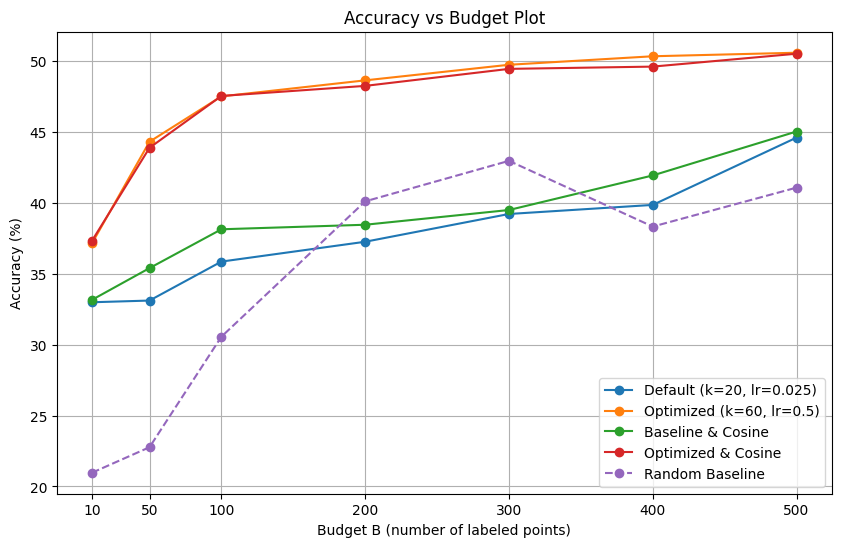

In [20]:
budgets = [10, 50, 100, 200, 300, 400, 500]

# results from above
paper_default = [33.00, 33.12, 35.87, 37.27, 39.23, 39.87, 44.62]
optimized = [37.16, 44.33, 47.53, 48.66, 49.76, 50.36, 50.61]
cosine = [33.17, 35.41, 38.15, 38.47, 39.51, 41.95, 45.05]
optimized_cosine = [37.34, 43.90, 47.56, 48.27, 49.47, 49.63, 50.54]
random_baseline_result = [20.97, 22.77, 30.57, 40.12, 42.98, 38.34, 41.09]

plt.figure(figsize=(10, 6))
plt.plot(budgets, paper_default, marker='o', label='Default (k=20, lr=0.025)')
plt.plot(budgets, optimized, marker='o', label='Optimized (k=60, lr=0.5)')
plt.plot(budgets, cosine, marker='o', label='Baseline & Cosine')
plt.plot(budgets, optimized_cosine, marker='o', label='Optimized & Cosine')
plt.plot(budgets, random_baseline, marker='o', label='Random Baseline', linestyle='--')

plt.xlabel('Budget B (number of labeled points)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Budget Plot')
plt.legend()
plt.grid(True)
plt.xticks(budgets)

# save
plt.savefig('/content/drive/MyDrive/accuracy_vs_budget_new.png', dpi=300, bbox_inches='tight')
plt.show()

k-Value and lr-Value Accuracy Plots

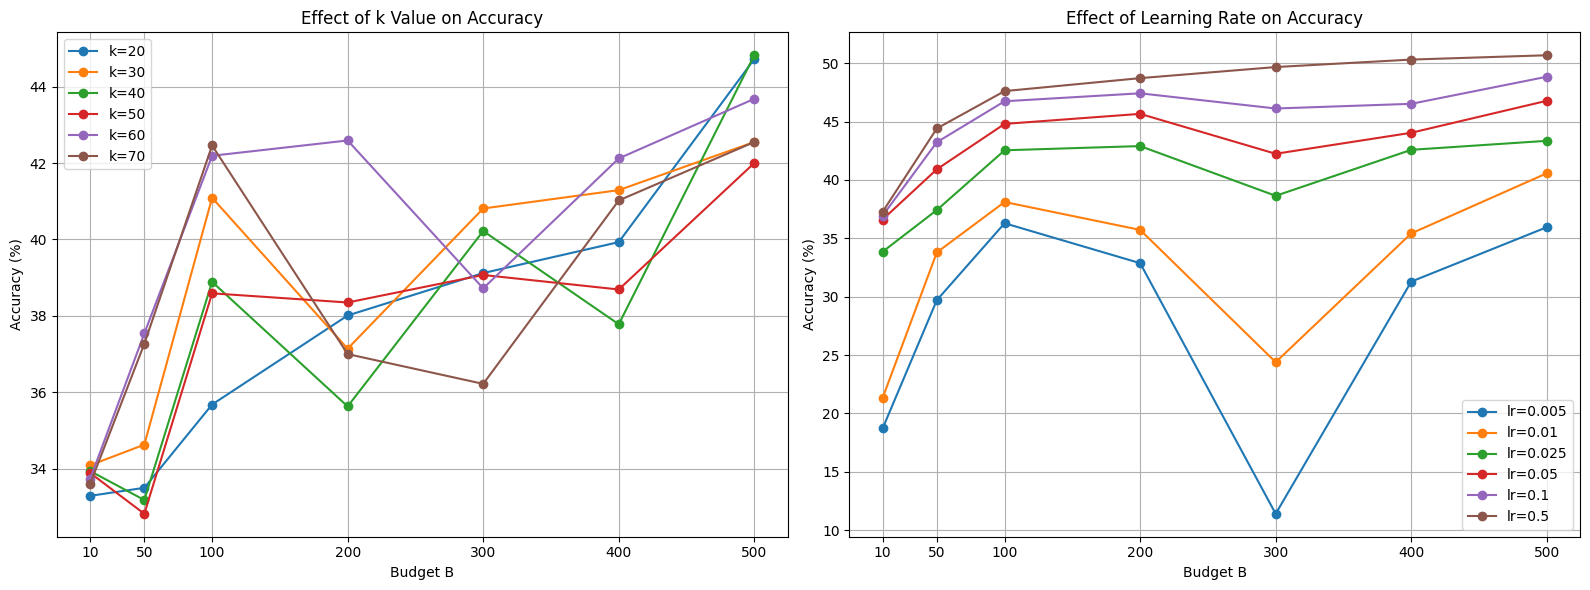

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

budgets = [10, 50, 100, 200, 300, 400, 500]

# k value results from above
k_results = {
    20: [33.29, 33.50, 35.68, 38.01, 39.12, 39.93, 44.72],
    30: [34.09, 34.63, 41.09, 37.14, 40.81, 41.29, 42.55],
    40: [33.94, 33.18, 38.89, 35.63, 40.22, 37.78, 44.82],
    50: [33.89, 32.82, 38.59, 38.35, 39.07, 38.69, 42.00],
    60: [33.73, 37.54, 42.19, 42.59, 38.72, 42.12, 43.68],
    70: [33.60, 37.27, 42.46, 37.00, 36.22, 41.02, 42.55]
}

for k, accuracies in k_results.items():
    ax1.plot(budgets, accuracies, marker='o', label=f'k={k}')

ax1.set_xlabel('Budget B')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Effect of k Value on Accuracy')
ax1.legend()
ax1.grid(True)
ax1.set_xticks(budgets)

# lr values from above
lr_results = {
    0.005: [18.71, 29.70, 36.29, 32.87, 11.40, 31.29, 35.95],
    0.01:  [21.32, 33.79, 38.11, 35.72, 24.39, 35.42, 40.57],
    0.025: [33.85, 37.42, 42.54, 42.90, 38.64, 42.58, 43.35],
    0.05:  [36.61, 40.91, 44.80, 45.66, 42.24, 44.04, 46.78],
    0.1:   [36.94, 43.23, 46.74, 47.42, 46.12, 46.52, 48.84],
    0.5:   [37.27, 44.41, 47.61, 48.72, 49.67, 50.31, 50.68]
}

for lr, accuracies in lr_results.items():
    ax2.plot(budgets, accuracies, marker='o', label=f'lr={lr}')

ax2.set_xlabel('Budget B')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Effect of Learning Rate on Accuracy')
ax2.legend()
ax2.grid(True)
ax2.set_xticks(budgets)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hyperparameter_search.png', dpi=300, bbox_inches='tight')
plt.show()